In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("C:\\Users\\vaish\\OneDrive\\Documents\\Adult_Income_Data_Cleaning_and_EDA\\data\\adult_income.csv")

In [3]:
df

,Age,Workclass,Fnlwgt,Education,Education_Num,Marital_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_Per_Week,Native_Country,Income,Source_Split,High_Income,Age_Group,Hour_Group,Net_Capital
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train,0,36-45,21-40,2174
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train,0,46-55,0-20,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train,0,36-45,21-40,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train,0,46-55,21-40,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train,0,26-35,21-40,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.,test,0,36-45,21-40,0
48838,64,Unknown,321403,HS-grad,9,Widowed,Unknown,Other-relative,Black,Male,0,0,40,United-States,<=50K.,test,0,56-65,21-40,0
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.,test,0,36-45,41-60,0
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.,test,0,36-45,21-40,5455


C:\Users\vaish\AppData\Local\Temp\ipykernel_27232\2177797121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


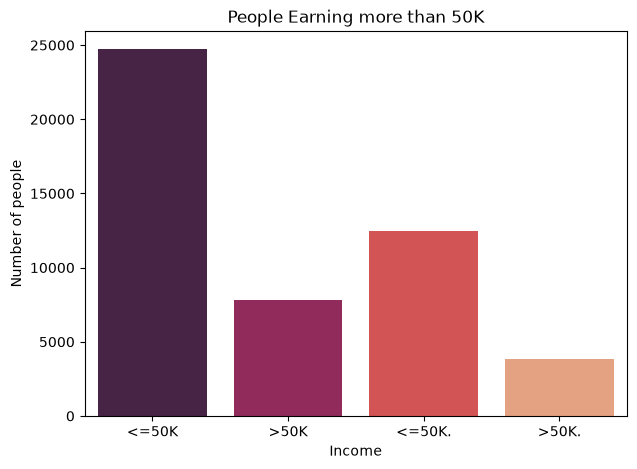

In [4]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Income",
    palette="rocket"
)

plt.title("People Earning more than 50K")
plt.xlabel("Income")
plt.ylabel("Number of people")

plt.show()

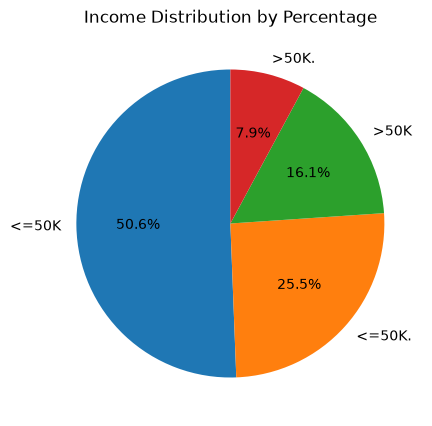

In [5]:
# calculating the percentage

income_perc=df["Income"].value_counts(normalize=True)*100

# graph visualising the percentage

plt.figure(figsize=(7,5))

df["Income"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    
)

plt.title("Income Distribution by Percentage")
plt.ylabel("")
plt.show()


Education
Doctorate       51.515152
Prof-school     50.719424
Masters         36.093338
Bachelors       27.676012
Assoc-voc       17.515769
Assoc-acdm      16.552155
Some-college    12.750506
HS-grad         10.612012
12th             5.022831
10th             4.463643
7th-8th          4.188482
9th              3.571429
11th             3.311258
5th-6th          3.143418
1st-4th          2.429150
Preschool        0.000000
Name: High_Income, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

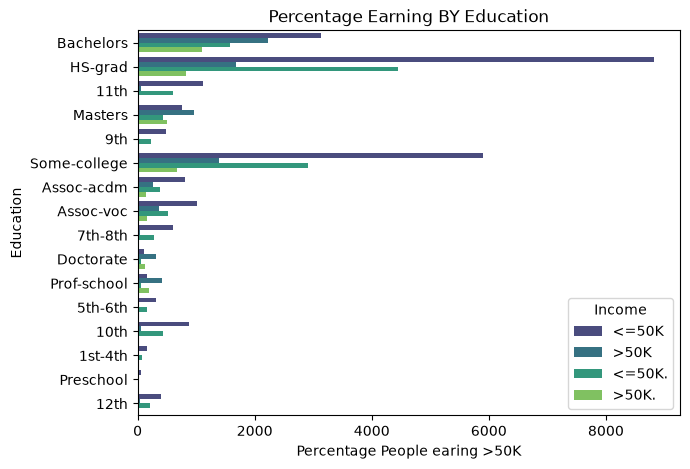

In [6]:
# income by education
edu_income=(
    df.groupby("Education")["High_Income"]
    .mean()
    .sort_values(ascending=False)*100
)
print(edu_income)


# Visualisation

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    y="Education",
    hue="Income",
    palette="viridis"
)

plt.title("Percentage Earning BY Education")
plt.xlabel("Percentage People earing >50K")
plt.ylabel("Education")
plt.show

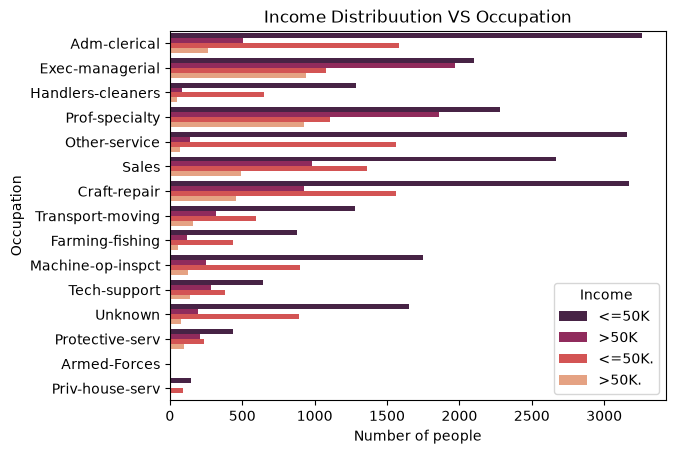

In [7]:
# income vs Occupation

# calculateing the percentage
occup_income=(
    df.groupby("Occupation")["High_Income"]
    .mean()
    .sort_values(ascending=False)*100
)

# visualisation

sns.countplot(
    data=df,
    y="Occupation",
    hue="Income",
    palette="rocket"
)

plt.title("Income Distribuution VS Occupation")
plt.xlabel("Number of people")
plt.ylabel("Occupation")
plt.show()


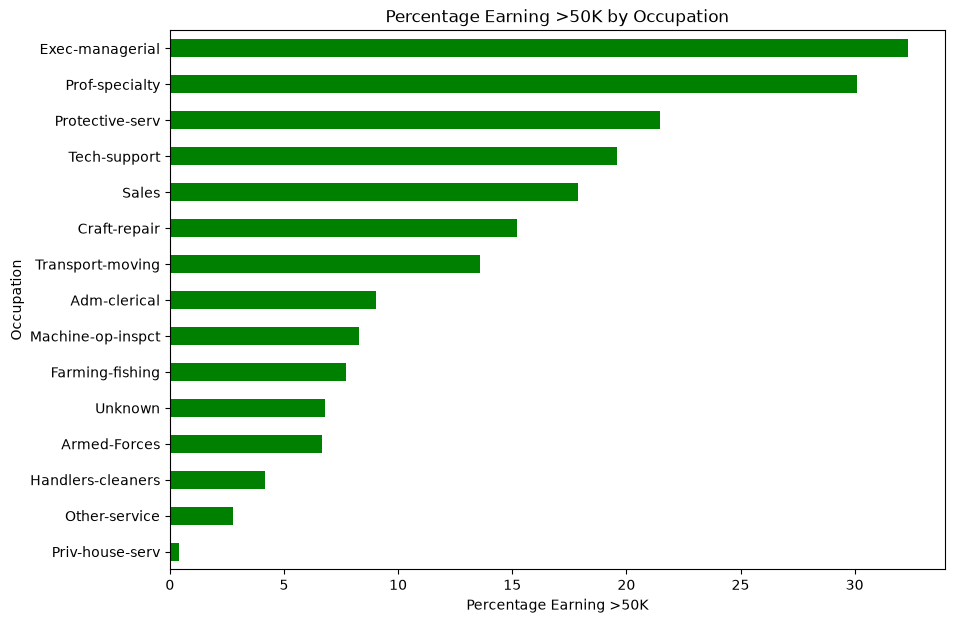

In [8]:
plt.figure(figsize=(10,7))

occup_income.sort_values().plot(kind="barh",
                                color='green')

plt.title("Percentage Earning >50K by Occupation")
plt.xlabel("Percentage Earning >50K")
plt.ylabel("Occupation")

plt.show()

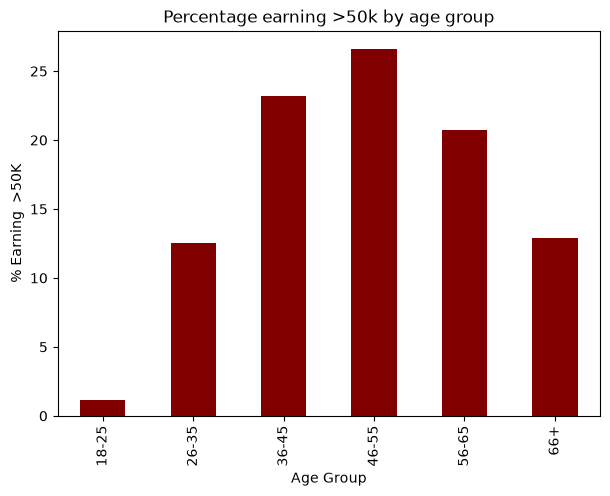

In [9]:
# Income by the age group

age_income=(
    df.groupby("Age_Group",observed=True)["High_Income"].mean()*100
)

# visualisation
plt.figure(figsize=(7,5))

age_income.plot(
    kind="bar",
    color="maroon",
)

plt.title("Percentage earning >50k by age group")
plt.xlabel("Age Group")
plt.ylabel("% Earning  >50K")
plt.show()

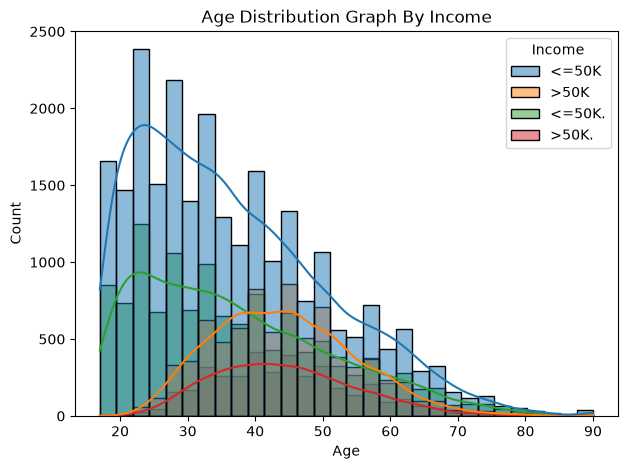

In [10]:
# Age distribution graph

plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x="Age",
    hue="Income",
    bins=30,
    kde=True
)

plt.title("Age Distribution Graph By Income")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

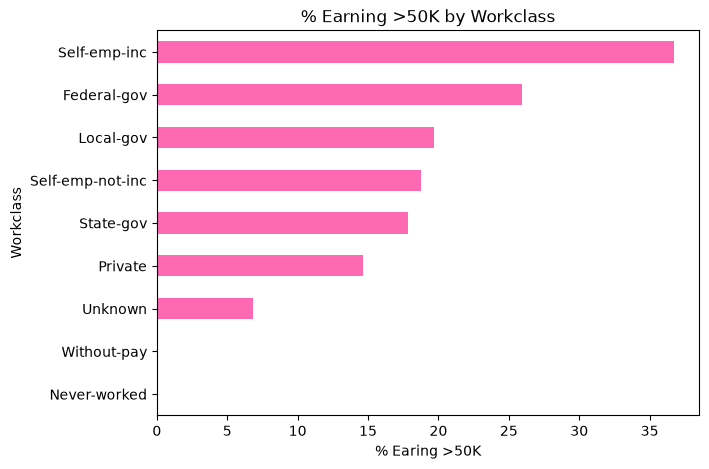

In [11]:
# icome by workclass graph

work_income=(df.groupby("Workclass")["High_Income"]
             .mean()
             .sort_values(ascending=False)*100

)

# Visualisation

plt.figure(figsize=(7,5))

work_income.sort_values().plot(
    kind="barh",
    color="hotpink"
)

plt.title("% Earning >50K by Workclass")
plt.xlabel("% Earing >50K")
plt.ylabel("Workclass")
plt.show()


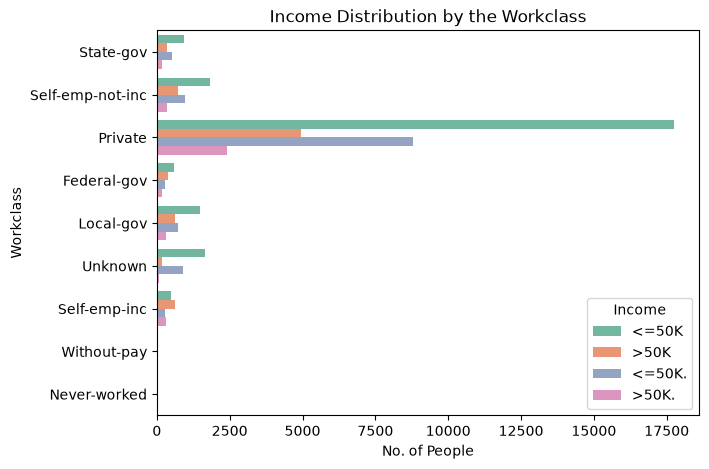

In [12]:
# Countplot of the workclass by income

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    y="Workclass",
    hue="Income",
    palette="Set2",
)

plt.title("Income Distribution by the Workclass")
plt.xlabel("No. of People")
plt.ylabel("Workclass")
plt.show()

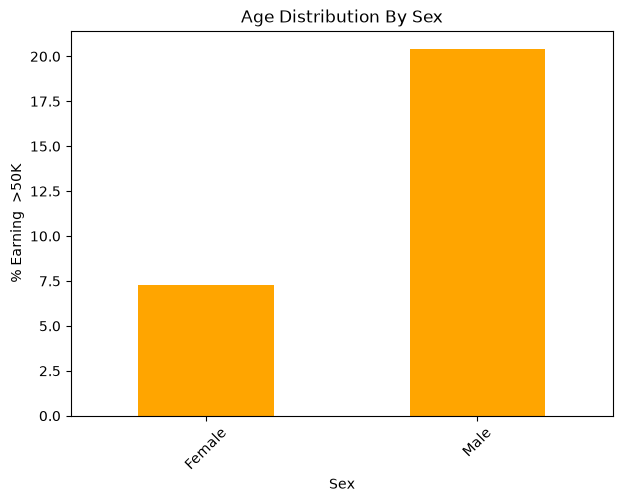

In [13]:
# Income by the sex graph

sex_income=(df.groupby("Sex")["High_Income"].mean()*100)

# Visualisation

plt.figure(figsize=(7,5))

sex_income.plot(
    kind="bar",
    color="orange",

)
plt.title("Age Distribution By Sex")
plt.xlabel("Sex")
plt.ylabel("% Earning  >50K")
plt.xticks(rotation=45)
plt.show()

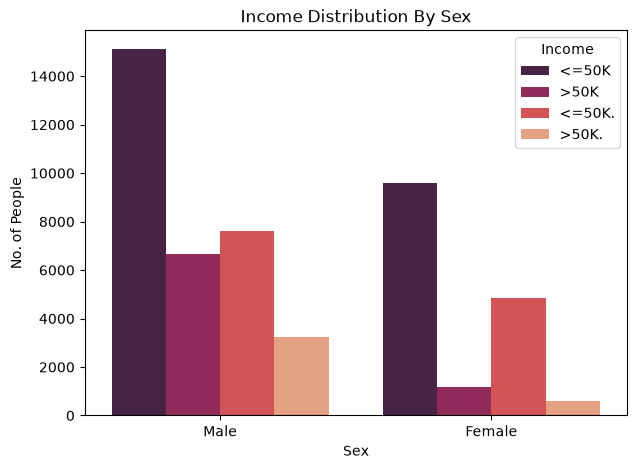

In [14]:
# countplot comparison

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Income",
    palette="rocket"
    
)
plt.title("Income Distribution By Sex")
plt.xlabel("Sex")
plt.ylabel("No. of People")
plt.show()

C:\Users\vaish\AppData\Local\Temp\ipykernel_27232\2348008313.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


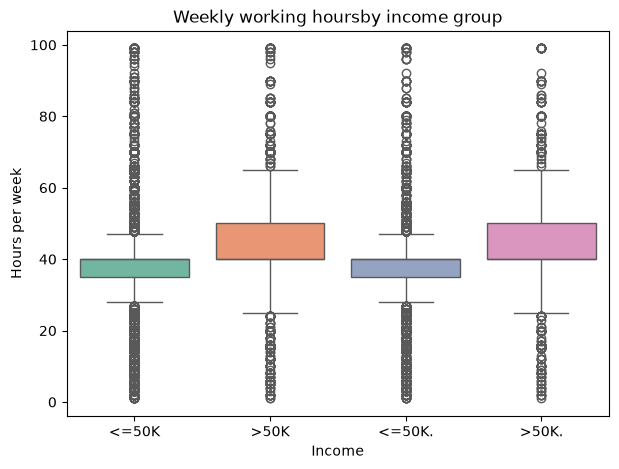

In [15]:
# Weekly morning hours VS income

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Income",
    y="Hours_Per_Week",
    palette="Set2"
)

plt.title("Weekly working hoursby income group")
plt.xlabel("Income")
plt.ylabel("Hours per week")
plt.show()

C:\Users\vaish\AppData\Local\Temp\ipykernel_27232\2762371347.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(


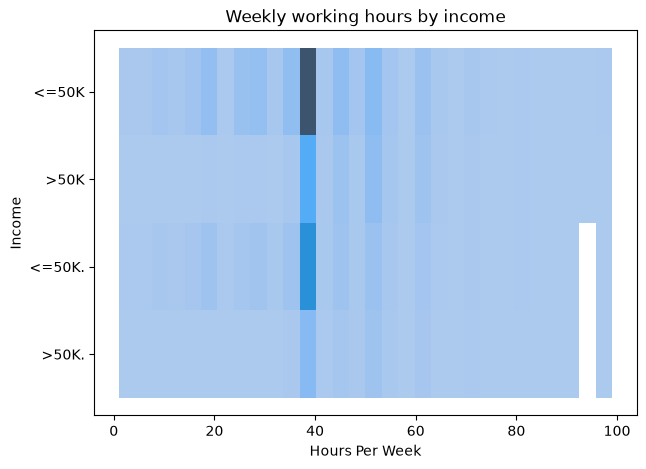

In [16]:
# Distribution graph

plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x="Hours_Per_Week",
    y="Income",
    bins=30,
    kde=True,
    element="step",
    palette="rocket"
)

plt.title("Weekly working hours by income")
plt.xlabel("Hours Per Week")
plt.ylabel("Income")
plt.show()

C:\Users\vaish\AppData\Local\Temp\ipykernel_27232\432284675.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


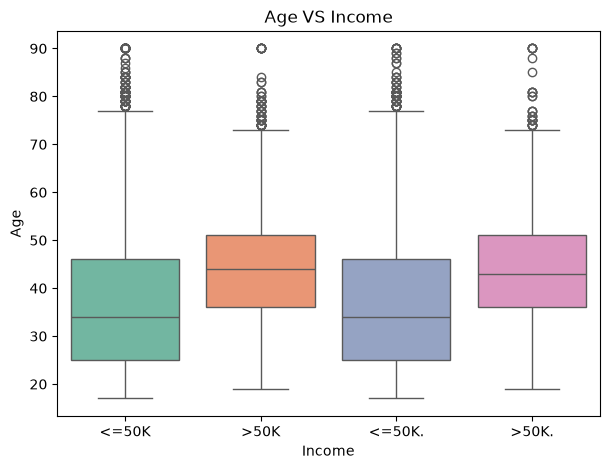

In [17]:
# age vs income graph
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Income",
    y="Age",
    palette="Set2"
)

plt.title("Age VS Income")
plt.xlabel("Income")
plt.ylabel("Age")
plt.show()

C:\Users\vaish\AppData\Local\Temp\ipykernel_27232\927092768.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


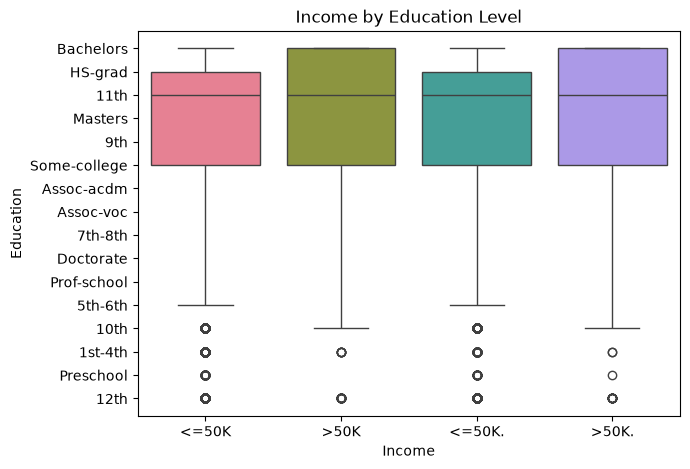

In [18]:
# education vs income

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Income",
    y="Education",
    palette="husl"

)
plt.title("Income by Education Level")
plt.xlabel("Income")
plt.ylabel("Education")
plt.show()

C:\Users\vaish\AppData\Local\Temp\ipykernel_27232\2971146081.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


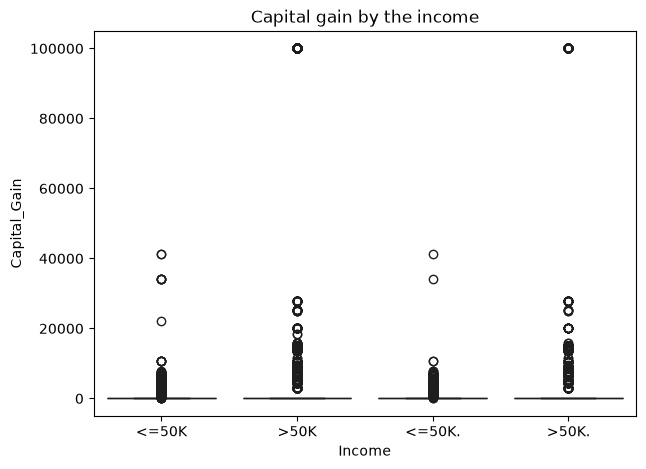

In [19]:
# Capital gain vs income

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Income",
    y="Capital_Gain",
    palette="cubehelix"
)

plt.title("Capital gain by the income")
plt.xlabel("Income")
plt.ylabel("Capital_Gain")
plt.show()

C:\Users\vaish\AppData\Local\Temp\ipykernel_27232\880381698.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


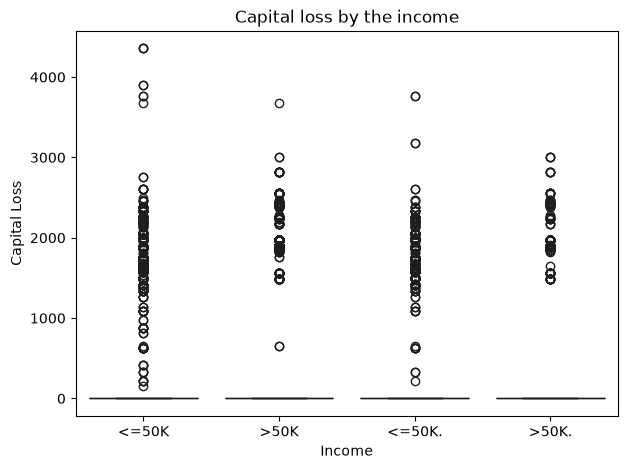

In [20]:
# Capital loss vs income

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Income",
    y="Capital_Loss",
    palette="cubehelix"
)

plt.title("Capital loss by the income")
plt.xlabel("Income")
plt.ylabel("Capital Loss")
plt.show()

C:\Users\vaish\AppData\Local\Temp\ipykernel_27232\3421288770.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


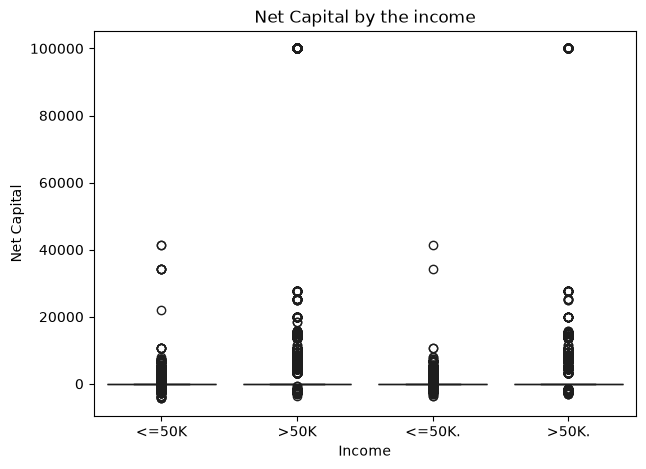

In [21]:
# Net Capital  vs income

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Income",
    y="Net_Capital",
    palette="cubehelix"
)

plt.title("Net Capital by the income")
plt.xlabel("Income")
plt.ylabel("Net Capital")
plt.show()